# Phase 11 · Suivi et réentraînement : carnet de travail

Le suivi mensuel du modèle en service, règle par règle, sur des **lots simulés** : aucun lot de production n'existe
encore, et le jeu de test ne se relit pas. Les règles (M1 à M10) et les données de démonstration (S1 à S8) ont été
validées par le porteur **avant tout calcul** (`docs/00.README_choix_methodologiques.md`, § 7 nonies).

> **SIMULÉ — démonstration.** Ce carnet prouve la **mécanique** du suivi — calculs, alertes, actions —, jamais la
> performance du modèle (S6).

In [1]:
# --- Environment: the project package and the recorded results --------------------------------
import json
import sys
from pathlib import Path

RACINE = Path.cwd()
for candidat in [RACINE, *RACINE.parents]:
    if (candidat / "src" / "churn_saas").is_dir():
        RACINE = candidat
        sys.path.insert(0, str(candidat / "src"))
        break

import matplotlib.pyplot as plt
import pandas as pd

from churn_saas.notebook import afficher_tableau

profil = json.loads((RACINE / "resultats" / "profil_reference.json").read_text(encoding="utf-8"))
rapport = json.loads((RACINE / "resultats" / "suivi_simule.json").read_text(encoding="utf-8"))
print(rapport["mention"], "—", rapport["portee"])

SIMULÉ — démonstration — mécanique du suivi démontrée ; aucune conclusion sur la performance (S6)


## 1. Les règles du suivi, fixées avant tout calcul

Chaque indicateur a un seuil, une action et un responsable : un indicateur sans seuil ne se surveille pas, un seuil
sans action ne sert à rien. Une alerte **avertit** et déclenche une qualification ; elle ne bloque jamais le scoring
(M6). Les responsables nommés restent à obtenir du commanditaire.

In [2]:
from churn_saas.monitoring import alertes, table_regles

afficher_tableau(table_regles(), titre="Règles d'alerte (M1 à M10)")
afficher_tableau(pd.DataFrame([
    ("M1", "Couverture du revenu à risque", f"≥ {alertes.CIBLE_COUVERTURE_REVENU:.0%}"),
    ("M3", "Réentraînement", f"tous les {alertes.FREQUENCE_REENTRAINEMENT_MOIS} mois, et sur alerte qualifiée"),
    ("M4", "Fenêtre de données", f"{alertes.FENETRE_REENTRAINEMENT_MOIS} mois glissants"),
    ("M5", "Variables clés", ", ".join(alertes.VARIABLES_CLES)),
    ("M8", "Manquants", f"> {alertes.FACTEUR_MANQUANTS:g} × la part d'entraînement"),
    ("M9", "Comptes signalés", f"écart > {alertes.ECART_VOLUME_SIGNALES:.0%} au mois précédent"),
], columns=["Règle", "Objet", "Valeur validée"]), titre="Valeurs par défaut validées le 04/10/2026")

indicateur,nature,seuil,action,responsable
PR-AUC en production,technique,baisse > 15 % vs référence,diagnostic puis réentraînement,Équipe Data
Couverture du revenu à risque,métier,< 50 % du MRR des comptes partis,révision de la capacité ou du modèle,Équipe Data + CSM
Dérive des entrées et du score (PSI),dérive,"> 0,25 sur une variable clé, ou > 0,10 sur trois variables, ou > 0,10 sur le score",qualification de l'alerte puis retour aux données,Équipe Data
Volume de comptes signalés,volumétrie,écart > 30 % vs mois précédent,contrôle qualité des données d'entrée,Équipe Data
Taux de manquants à l'entrée,qualité,"> 2 × le taux d'entraînement, sur une variable","avertissement, scoring maintenu ; qualification de la collecte",Équipe Data
Rappel sur le segment Suisse,équité,"< 0,8 × rappel global, intervalle excluant le rappel global (critère R9)","revue du segment avec les CSM, sans correction automatique",Équipe Data + CSM
Rétention des comptes traités,métier,non significative vs témoin,remise en cause de l'utilité de l'outil,Commanditaire
Retours de faux positifs CSM,métier,volume anormal,révision du point de fonctionnement,CSM + Équipe Data


Règle,Objet,Valeur validée
M1,Couverture du revenu à risque,≥ 50%
M3,Réentraînement,"tous les 3 mois, et sur alerte qualifiée"
M4,Fenêtre de données,12 mois glissants
M5,Variables clés,"derniere_connexion_jours, anciennete_mois, nb_integrations, tickets_support_90j"
M8,Manquants,> 2 × la part d'entraînement
M9,Comptes signalés,écart > 30% au mois précédent


## 2. Le profil de référence

Le suivi compare chaque lot à un **profil**, pas aux lignes d'entraînement : bornes et parts de chaque variable et du
score, et part d'absents telle que reçue. Aucune donnée de compte ne part en production. Le profil désigne le modèle
auquel il appartient : un nouveau champion sans nouveau profil fait échouer un test (§ 13 : la référence se versionne
avec le modèle).

In [3]:
print(f"Modèle : {profil['modele']['nom']} {profil['modele']['version']} — {profil['comptes']} comptes d'entraînement")
afficher_tableau(pd.DataFrame({
    "variable": list(profil["manquants_a_l_entree"]),
    "variable clé": [v in profil["variables_cles"] for v in profil["manquants_a_l_entree"]],
    "absents à l'entraînement": [f"{p:.1%}" for p in profil["manquants_a_l_entree"].values()],
    "seuil M8": [f"{2 * p:.1%}" for p in profil["manquants_a_l_entree"].values()],
}), titre="Profil de référence : variables et parts d'absents")

Modèle : churn_saas_servi 1.1 — 4000 comptes d'entraînement


variable,variable clé,absents à l'entraînement,seuil M8
jour_souscription,False,0.0%,0.0%
secteur,False,4.9%,9.8%
taille_entreprise,False,0.0%,0.0%
plan,False,0.0%,0.0%
anciennete_mois,True,0.0%,0.0%
sieges_souscrits,False,0.0%,0.0%
utilisateurs_actifs,False,0.0%,0.0%
taux_adoption_pct,False,4.8%,9.5%
connexions_30j,False,0.0%,0.0%
heures_usage_30j,False,6.2%,12.3%


## 3. Les lots simulés

Trois lots de 5 000 comptes, au format brut de l'export du CRM : les **36 comptes de l'échantillon qui appartiennent à
la partie d'entraînement** — les 14 du jeu de test sont refusés par un contrôle —, complétés par tirage dans la partie
d'entraînement (graine 42).

| Mois | Scénario | Règle visée |
|---|---|---|
| 1 | aucune dérive | témoin : aucune alerte attendue |
| 2 | dernière connexion **× 2** sur 30 % des comptes ; délai du support absent sur 25 % | M5, M8 |
| 3 | dernière connexion **+ 30 jours** sur 30 % des comptes, rien d'autre | M5 (décision S8, prise après le mois 2) |

In [4]:
manifeste = json.loads((RACINE / "data" / "simulation" / "manifeste_simulation.json").read_text(encoding="utf-8"))
print(manifeste["mention"], "| comptes réels :", manifeste["comptes_reels"])
afficher_tableau(pd.DataFrame([
    {"fichier": nom, "lignes": f["lignes"], "empreinte": f["sha256"][:12] + "…"}
    for nom, f in manifeste["fichiers"].items()
]), titre="Lots simulés (data/simulation/, versionnés)")

SIMULÉ — démonstration | comptes réels : {"retenus (partie d'entraînement)": 36, 'écartés (jeu de test)': 14}


fichier,lignes,empreinte
lot_simule_mois_1_sans_derive.csv,5000,61e5f664ab9c…
lot_simule_mois_2_avec_derive.csv,5000,acc0e5272991…
lot_simule_mois_3_derive_forte.csv,5000,e51ae9b8c871…


## 4. L'évolution de la dérive, mois après mois (M5)

M5 se déclenche si une **variable clé** dépasse 0,25, si **trois variables** dépassent 0,10, ou si le **score**
dépasse 0,10.

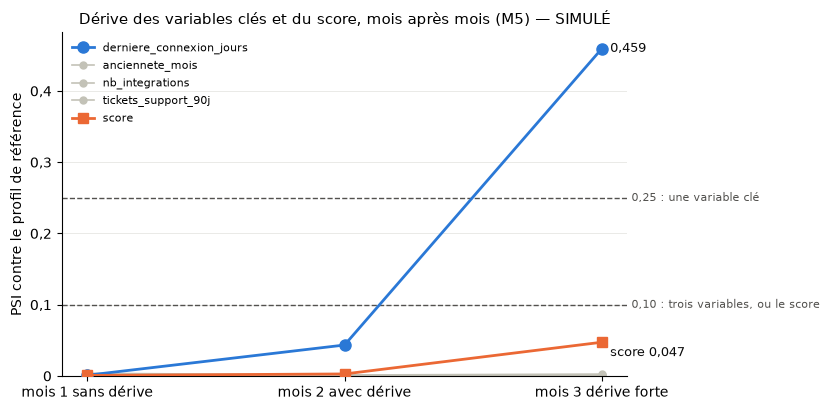

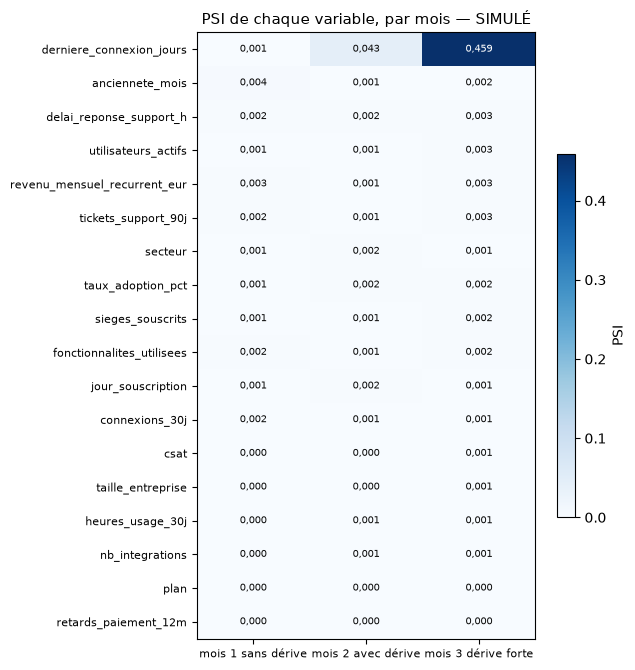

mois,PSI dernière connexion,PSI du score,M5 déclenchée
mois_1_sans_derive,0.0010,0.0007,False
mois_2_avec_derive,0.0434,0.0028,False
mois_3_derive_forte,0.4593,0.0473,True


In [5]:
from churn_saas.features import tracer_carte_psi, tracer_evolution_psi

tracer_evolution_psi(rapport["mois"], profil["variables_cles"], "derniere_connexion_jours",
                     (alertes.SEUIL_PSI_MODERE, alertes.SEUIL_PSI_VARIABLE_CLE))
plt.show()
tracer_carte_psi(rapport["mois"])
plt.show()
afficher_tableau(pd.DataFrame([{
    "mois": m["mois"],
    "PSI dernière connexion": m["M5_derive"]["psi"]["derniere_connexion_jours"],
    "PSI du score": m["M5_derive"]["verdict"]["psi du score"],
    "M5 déclenchée": m["M5_derive"]["verdict"]["déclenchée"],
} for m in rapport["mois"]]), titre="M5 par mois")

## 5. Pourquoi doubler la dernière connexion ne suffit pas — et pourquoi + 30 jours suffit

La variable est concentrée sur de petites valeurs : la moitié des comptes se sont connectés il y a deux jours au plus.
Doublées, ces valeurs ne changent de tranche qu'une fois ; ajouter 30 jours envoie 30 % des comptes au-delà du dernier
décile. Le PSI compare ces parts tranche par tranche.

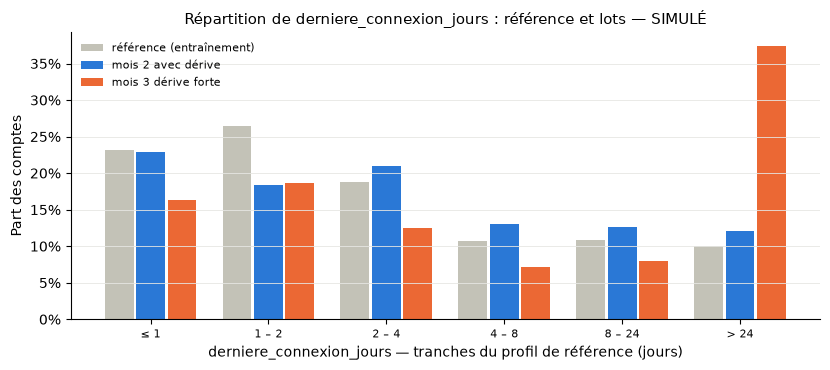

In [6]:
from churn_saas.features import construire_silver_standard, preparer_gold, tracer_deciles
from churn_saas.monitoring import parts_selon_profil

variable = "derniere_connexion_jours"
reference = profil["variables"][variable]
catalogue = pd.read_csv(RACINE / "data" / "raw" / "catalogue_plans.csv", dtype=str, encoding="utf-8-sig")
parts = {"référence (entraînement)": reference["parts"]}
for m in rapport["mois"][1:]:
    brut = pd.read_csv(RACINE / "data" / "simulation" / f"lot_simule_{m['mois']}.csv", dtype=str,
                       encoding="utf-8-sig")
    gold = preparer_gold(construire_silver_standard(brut, catalogue=catalogue)).gold
    parts[m["mois"].replace("_", " ").replace("derive", "dérive")] = parts_selon_profil(reference, gold[variable])
tracer_deciles(reference["bornes_internes"], parts, variable)
plt.show()

## 6. Les manquants à l'entrée (M8)

Chaque variable est jugée contre le **double de sa part d'absents à l'entraînement**, telle que reçue, avant toute
reconstruction ; une variable jamais absente alerte dès sa première absence.

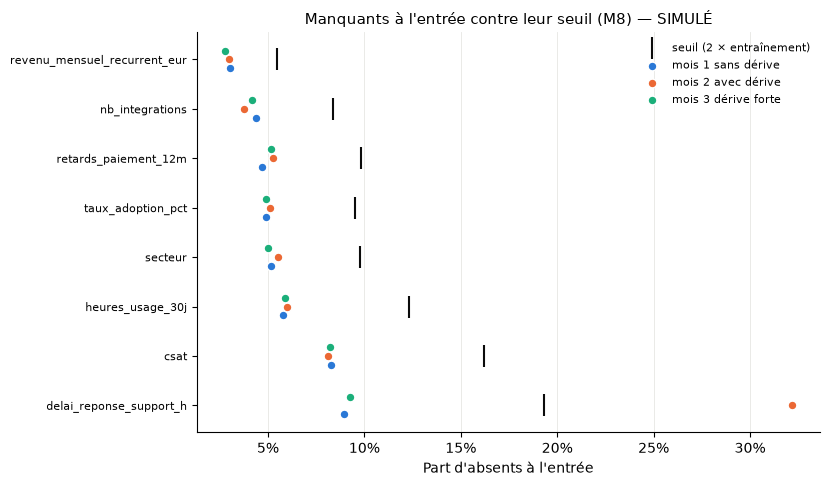

mois_1_sans_derive → aucune variable en alerte
mois_2_avec_derive → ['delai_reponse_support_h']
mois_3_derive_forte → aucune variable en alerte


In [7]:
from churn_saas.features import tracer_manquants

tracer_manquants(rapport["mois"], alertes.FACTEUR_MANQUANTS)
plt.show()
for m in rapport["mois"]:
    print(m["mois"], "→", m["M8_manquants"]["verdict"]["variables en alerte"] or "aucune variable en alerte")

## 7. Les comptes signalés (M9)

Les comptes retenus par la liste — à contacter et groupe témoin —, comparés au mois précédent.

In [8]:
afficher_tableau(pd.DataFrame([{"mois": m["mois"], **m["M9_volume"]} for m in rapport["mois"]]),
                 titre="Comptes signalés, mois après mois (M9)")

mois,comptes signalés,mois précédent,écart,déclenchée
mois_1_sans_derive,156,NaN,NaN,False
mois_2_avec_derive,156,156.0,0.0,False
mois_3_derive_forte,156,156.0,0.0,False


## 8. Les alertes de chaque mois, et ce qu'elles déclenchent

In [9]:
for m in rapport["mois"]:
    table = pd.DataFrame(m["alertes"])
    afficher_tableau(table[table["indicateur"].isin(["Dérive des entrées et du score (PSI)",
                                                      "Taux de manquants à l'entrée",
                                                      "Volume de comptes signalés"])],
                     titre=f"Alertes — {m['mois']}")

indicateur,seuil,declenchee,action,responsable
Dérive des entrées et du score (PSI),"> 0,25 sur une variable clé, ou > 0,10 sur trois variables, ou > 0,10 sur le score",False,—,—
Volume de comptes signalés,écart > 30 % vs mois précédent,False,—,—
Taux de manquants à l'entrée,"> 2 × le taux d'entraînement, sur une variable",False,—,—


indicateur,seuil,declenchee,action,responsable
Dérive des entrées et du score (PSI),"> 0,25 sur une variable clé, ou > 0,10 sur trois variables, ou > 0,10 sur le score",False,—,—
Volume de comptes signalés,écart > 30 % vs mois précédent,False,—,—
Taux de manquants à l'entrée,"> 2 × le taux d'entraînement, sur une variable",True,"avertissement, scoring maintenu ; qualification de la collecte",Équipe Data


indicateur,seuil,declenchee,action,responsable
Dérive des entrées et du score (PSI),"> 0,25 sur une variable clé, ou > 0,10 sur trois variables, ou > 0,10 sur le score",True,qualification de l'alerte puis retour aux données,Équipe Data
Volume de comptes signalés,écart > 30 % vs mois précédent,False,—,—
Taux de manquants à l'entrée,"> 2 × le taux d'entraînement, sur une variable",False,—,—


## 9. La revue trimestrielle, sur des issues simulées (partie B)

À trois mois, l'issue de chaque compte — contacté, témoin ou non retenu — est **tirée** selon la probabilité du modèle,
réduite de 25 % pour les comptes contactés (hypothèse d'efficacité, S5). La revue en tire quatre verdicts : couverture
du revenu à risque (M1), rappel sur le segment Suisse (M7, critère R9), efficacité des contacts contre le groupe
témoin, PR-AUC sur les comptes non contactés. Des issues tirées du modèle le rendent **juste par construction** : ces
chiffres exercent la revue, ils ne mesurent rien du modèle (S6).

In [10]:
revue = rapport["revue_trimestrielle"]
print(revue["mention"], "—", revue["comptes"], "comptes sur le trimestre")
afficher_tableau(pd.DataFrame([
    ("M1 · couverture du revenu à risque", f"{revue['M1_couverture']['part couverte']:.1%}", "≥ 50 %",
     revue["M1_couverture"]["déclenchée"]),
    ("M7 · rappel, segment Suisse", f"{revue['M7_suisse']['rappel']:.3f} (global {revue['M7_suisse']['rappel global']:.3f})",
     "critère R9", revue["M7_suisse"]["déclenchée"]),
    ("Efficacité contre témoin", f"{revue['retention_contre_temoin']['efficacité mesurée']:.1%} "
     f"[{revue['retention_contre_temoin']['intervalle 95 %'][0]:.0%} ; {revue['retention_contre_temoin']['intervalle 95 %'][1]:.0%}]",
     "intervalle au-dessus de 0", revue["retention_contre_temoin"]["déclenchée"]),
    ("PR-AUC en production", f"{revue['pr_auc_en_production']['PR-AUC']:.3f}",
     f"baisse ≤ 15 % vs {revue['pr_auc_en_production']['référence']}", revue["pr_auc_en_production"]["déclenchée"]),
], columns=["Indicateur", "Mesure (SIMULÉE)", "Règle", "Alerte"]), titre="Revue trimestrielle — SIMULÉ")
print("Comptes témoins sur le trimestre :", revue["retention_contre_temoin"]["comptes témoins"])

SIMULÉ — démonstration — 15000 comptes sur le trimestre


Indicateur,Mesure (SIMULÉE),Règle,Alerte
M1 · couverture du revenu à risque,49.9%,≥ 50 %,True
"M7 · rappel, segment Suisse",0.063 (global 0.053),critère R9,False
Efficacité contre témoin,8.6% [-23% ; 28%],intervalle au-dessus de 0,True
PR-AUC en production,0.805,baisse ≤ 15 % vs 0.7612,False


Comptes témoins sur le trimestre : 48


## 10. Le réentraînement : quelles données, et quand (partie C)

**Les données (M2, M4)** : les comptes contactés sont exclus — le contact a changé leur issue, le modèle apprendrait
l'effet de l'action plutôt que le risque ; le groupe témoin et les comptes non contactés sont gardés, sur douze mois
glissants. **Le moment (M3)** : chaque trimestre, et plus tôt sur une alerte **qualifiée** de dérive réelle ; une
alerte qualifiée d'incident de collecte renvoie aux données, pas au réentraînement. La qualification est la décision
d'une personne : ici, elle est **simulée** à partir du scénario connu qui a produit chaque alerte.

In [11]:
partie_c = rapport["reentrainement"]
afficher_tableau(pd.DataFrame([partie_c["selection"]]).astype(str), titre="Données de réentraînement (M2, M4) — SIMULÉ")
afficher_tableau(pd.DataFrame([{
    "mois": d["mois"],
    "alertes qualifiées": "; ".join(f"{a['indicateur']} → {a['qualification']}" for a in d["alertes qualifiées (SIMULÉ)"]) or "—",
    "réentraîner": d["réentraîner"],
    "motifs": "; ".join(d["motifs"]) or "—",
} for d in partie_c["decisions"]]), titre="Décision de réentraînement, mois après mois (M3) — SIMULÉ")

fenêtre,lignes reçues,hors fenêtre,"contactés, exclus (M2)","issue inconnue, écartés",retenus,dont témoins,taux de départ des retenus
"['2026-04-01', '2027-04-01']",15000,0,420,0,14580,48,0.2999


mois,alertes qualifiées,réentraîner,motifs
mois_1_sans_derive,—,False,—
mois_2_avec_derive,Taux de manquants à l'entrée → incident de collecte,False,—
mois_3_derive_forte,Dérive des entrées et du score (PSI) → dérive réelle,True,échéance trimestrielle (3 mois depuis le dernier entraînement); dérive réelle qualifiée : Dérive des entrées et du score (PSI)


## 11. Constats et limites

- **Le dispositif fonctionne** : le mois sans dérive reste muet, l'incident de collecte du mois 2 est vu (M8), le
  désengagement marqué du mois 3 aussi (M5) — et M8 retombe quand la collecte est rétablie.
- **La sensibilité de M5 est un constat, pas un défaut du code** : un désengagement réel mais modeste (× 2 sur 30 % des
  comptes) reste sous les seuils. Il faut le savoir pour lire un tableau de bord vert.
- **Le score bouge peu**, même en dérive forte : la condition « score au-dessus de 0,10 » ne se déclencherait qu'avec
  une dérive large, sur plusieurs variables.
- **Le groupe témoin est trop petit pour conclure en un trimestre** : 10 % d'une liste de 156 comptes, soit une
  cinquantaine de témoins, donnent un intervalle d'efficacité qui contient zéro. Prouver l'effet des contacts
  demandera plusieurs trimestres cumulés, ou un témoin plus large — un arbitrage pour le commanditaire.
- **La couverture du revenu frôle la cible** : les contacts réduisent les départs des comptes signalés, donc la part
  du revenu perdu qu'ils représentent ; la cible de 50 % se lit avec cet effet en tête.
- **Limite (S6)** : les lots et les issues sont simulés à partir de la partie d'entraînement. Rien ici ne mesure la performance du
  modèle ; la couverture, le rappel par segment et l'effet des contacts se mesureront sur les issues réelles de
  **tous** les comptes, à demander au commanditaire.

In [12]:
mois_2, mois_3 = rapport["mois"][1], rapport["mois"][2]
print("Mois 2 — PSI dernière connexion :", mois_2["M5_derive"]["psi"]["derniere_connexion_jours"],
      "| M5 :", mois_2["M5_derive"]["verdict"]["déclenchée"])
print("Mois 3 — PSI dernière connexion :", mois_3["M5_derive"]["psi"]["derniere_connexion_jours"],
      "| PSI du score :", mois_3["M5_derive"]["verdict"]["psi du score"],
      "| M5 :", mois_3["M5_derive"]["verdict"]["déclenchée"])

Mois 2 — PSI dernière connexion : 0.0434 | M5 : False
Mois 3 — PSI dernière connexion : 0.4593 | PSI du score : 0.0473 | M5 : True
